Dominant Pollutant Distribution:
dominant_pollutant
O3       18492
PM2.5     3853
PM10      2793
SO2       1780
Dust      1614
NO2        386
CO          93
Name: count, dtype: int64

Sample rows:
           datetime  AQI  aqi_category dominant_pollutant
0  06-08-2022 05:00   46          Good                 O3
1  06-08-2022 06:00   40          Good                 O3
2  06-08-2022 07:00   41          Good                SO2
3  06-08-2022 08:00   51  Satisfactory                SO2
4  06-08-2022 09:00   60  Satisfactory                SO2
5  06-08-2022 10:00   69  Satisfactory                SO2
6  06-08-2022 11:00   77  Satisfactory                SO2
7  06-08-2022 12:00  500        Severe                SO2
8  06-08-2022 13:00   87  Satisfactory                 O3
9  06-08-2022 14:00  119      Moderate                 O3

Dataset saved with dominant_pollutant column!


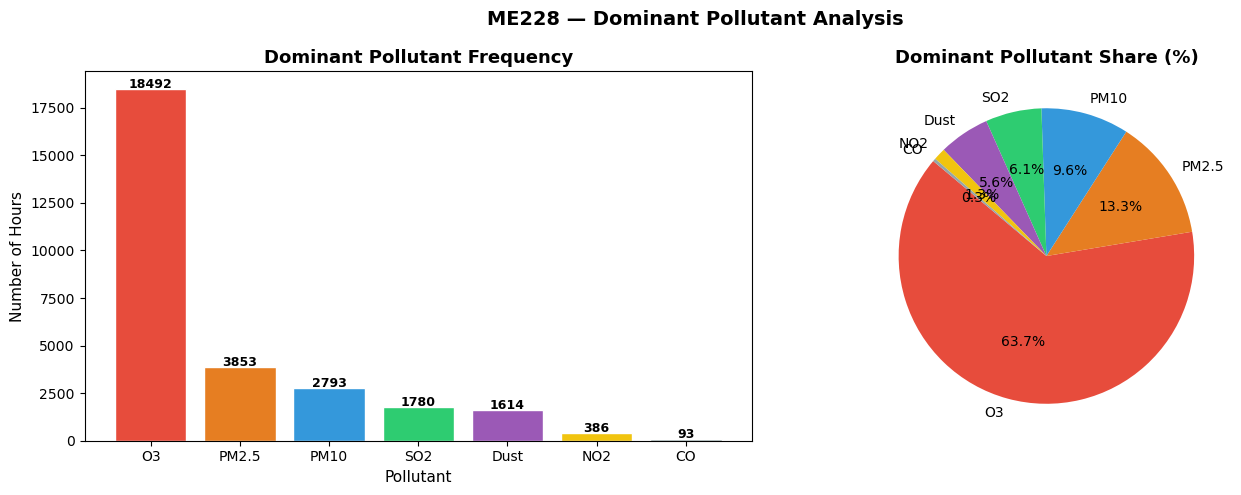

Plot saved as ME228_Dominant_Pollutant.png


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('ME228_Clean_Dataset.csv')

# Normalize pollutants by CPCB 24hr safe limits for fair comparison
limits = {
    'pm2_5_ugm3': 60,
    'pm10_ugm3':  100,
    'co_ugm3':    2000,
    'no2_ugm3':   80,
    'so2_ugm3':   80,
    'o3_ugm3':    100,
    'dust_ugm3':  100
}

pollutants = list(limits.keys())
labels     = ['PM2.5', 'PM10', 'CO', 'NO2', 'SO2', 'O3', 'Dust']

# Create normalized columns
for p, limit in limits.items():
    df[f'{p}_norm'] = df[p] / limit

norm_cols = [f'{p}_norm' for p in pollutants]

# Dominant pollutant = whichever has highest normalized value
df['dominant_pollutant'] = df[norm_cols].idxmax(axis=1)
df['dominant_pollutant'] = df['dominant_pollutant'].map(dict(zip(norm_cols, labels)))

# Drop temp norm columns
df = df.drop(columns=norm_cols)

# Print distribution
print("Dominant Pollutant Distribution:")
print(df['dominant_pollutant'].value_counts())
print()
print("Sample rows:")
print(df[['datetime', 'AQI', 'aqi_category', 'dominant_pollutant']].head(10))

# Save updated dataset
df.to_csv('ME228_Clean_Dataset.csv', index=False)
print("\nDataset saved with dominant_pollutant column!")

# Plot: dominant pollutant distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
colors = ['#e74c3c','#e67e22','#3498db','#2ecc71','#9b59b6','#f1c40f','#95a5a6']
counts = df['dominant_pollutant'].value_counts()
axes[0].bar(counts.index, counts.values, color=colors[:len(counts)], edgecolor='white')
axes[0].set_xlabel('Pollutant', fontsize=11)
axes[0].set_ylabel('Number of Hours', fontsize=11)
axes[0].set_title('Dominant Pollutant Frequency', fontsize=13, fontweight='bold')
for i, (val) in enumerate(counts.values):
    axes[0].text(i, val + 50, str(val), ha='center', fontsize=9, fontweight='bold')

# Pie chart
axes[1].pie(counts.values, labels=counts.index, colors=colors[:len(counts)],
            autopct='%1.1f%%', startangle=140, textprops={'fontsize': 10})
axes[1].set_title('Dominant Pollutant Share (%)', fontsize=13, fontweight='bold')

plt.suptitle('ME228 — Dominant Pollutant Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('ME228_Dominant_Pollutant.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved as ME228_Dominant_Pollutant.png")